In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("bitcoin.csv")
df.head()

,Date,Price
0,5/23/2019,7881.846680
1,5/24/2019,7987.371582
2,5/25/2019,8052.543945
3,5/26/2019,8673.215820
4,5/27/2019,8805.778320


In [ ]:
df.drop(['Date'],axis=1,inplace=True)

In [ ]:
predictionDays = 30
# Create another column shifted 'n'  units up
df['Prediction'] = df[['Price']].shift(-predictionDays)
# show the first 5 rows
df.head()

,Price,Prediction
0,7881.846680,10701.69141
1,7987.371582,10855.37109
2,8052.543945,11011.10254
3,8673.215820,11790.91699
4,8805.778320,13016.23145


In [ ]:
X = np.array(df.drop(['Prediction'], axis=1))
X = X[:-predictionDays]

y = np.array(df['Prediction'])
y = y[:-predictionDays]

In [ ]:
df.tail()

,Price,Prediction
362,9729.038086,NaN
363,9522.981445,NaN
364,9081.761719,NaN
365,9182.577148,NaN
366,9180.045898,NaN


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Split the data into 80% training and 20% testing
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2)
# set the predictionDays array equal to last 30 rows from the original data set
predictionDays_array = np.array(df.drop(['Prediction'],axis=1))[-predictionDays:]
print(predictionDays_array)

[[7550.900879]
 [7569.936035]
 [7679.867188]
 [7795.601074]
 [7807.058594]
 [8801.038086]
 [8658.553711]
 [8864.766602]
 [8988.59668 ]
 [8897.46875 ]
 [8912.654297]
 [9003.070313]
 [9268.761719]
 [9951.518555]
 [9842.666016]
 [9593.896484]
 [8756.430664]
 [8601.795898]
 [8804.477539]
 [9269.987305]
 [9733.72168 ]
 [9328.197266]
 [9377.013672]
 [9670.739258]
 [9726.575195]
 [9729.038086]
 [9522.981445]
 [9081.761719]
 [9182.577148]
 [9180.045898]]


In [ ]:
from sklearn.svm import SVR
# Create and Train the Support Vector Machine (Regression) using radial basis function
svr_rbf = SVR(kernel='rbf', C=1e3, gamma=0.00001)
svr_rbf.fit(xtrain, ytrain)

SVR(C=1000.0, gamma=1e-05)

In [ ]:
svr_rbf = SVR(kernel='rbf', C=1e3, gamma=0.00001)
svr_rbf.fit(X_train_scaled, y_train)

SVR(C=1000.0, gamma=1e-05)

In [ ]:
# print the predicted values
svm_prediction = svr_rbf.predict(xtest)
print(svm_prediction)
print()
print(ytest)

[8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483 8808.81371483 8808.81371483
 8808.81371483 8808.81371483 8808.81371483]

[ 6416.314941  7193.599121  7679

R2 Score: -0.007169295619569693
RMSE: 1539.9541958083312


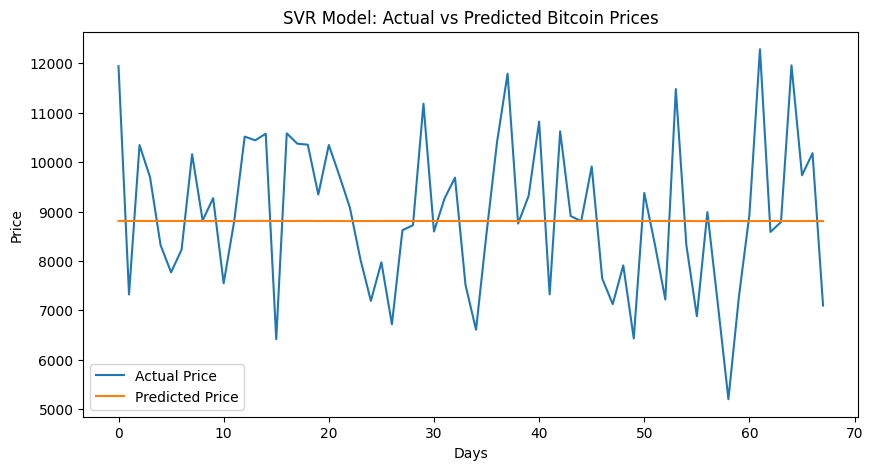

In [ ]:
y_pred = svr_rbf.predict(X_test_scaled)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Plot actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title("SVR Model: Actual vs Predicted Bitcoin Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
# Print the model predictions for the next 30 days
prediction_days_array = np.array(df.drop(['Prediction'], axis=1))[-predictionDays:]
prediction_days_array_scaled = scaler.transform(prediction_days_array)
future_prediction = svr_rbf.predict(prediction_days_array_scaled)

print("Predicted Bitcoin Prices for Next 30 Days:")
print(future_prediction)

print("Actual Bitcoin Prices for Last 30 Days:")
print(df.tail(predictionDays))

Predicted Bitcoin Prices for Next 30 Days:
[8807.65617    8807.67104744 8807.75696733 8807.8474229  8807.85637791
 8808.63326608 8808.52190039 8808.68307628 8808.77986189 8808.70863628
 8808.7205053  8808.79117448 8808.99883892 8809.53247914 8809.44740084
 8809.25296376 8808.59840093 8808.47753856 8808.63595435 8808.99979684
 8809.36225058 8809.04529371 8809.08344858 8809.3130238  8809.35666492
 8809.3585899  8809.19753676 8808.85267971 8808.93147707 8808.92949864]
Actual Bitcoin Prices for Last 30 Days:
           Price  Prediction
337  7550.900879         NaN
338  7569.936035         NaN
339  7679.867188         NaN
340  7795.601074         NaN
341  7807.058594         NaN
342  8801.038086         NaN
343  8658.553711         NaN
344  8864.766602         NaN
345  8988.596680         NaN
346  8897.468750         NaN
347  8912.654297         NaN
348  9003.070313         NaN
349  9268.761719         NaN
350  9951.518555         NaN
351  9842.666016         NaN
352  9593.896484         N